# Comecando a Analise Exploratoria

In [1]:
import pandas as pd
import os 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

In [2]:
df = pd.read_csv("csvs/feminicidios_2022_2025.csv", encoding="utf-8-sig")
df.head()

,ANO_BO,ANO_ESTATISTICA,BAIRRO,DATA_OCORRENCIA_BO,DESCR_CONDUTA,DESC_PERIODO,HORA_OCORRENCIA_BO,LATITUDE,LOGRADOURO,LONGITUDE,...,NOME_DELEGACIA_CIRCUNSCRICAO,NOME_DEPARTAMENTO,NOME_DEPARTAMENTO_CIRCUNSCRICAO,NOME_MUNICIPIO,NOME_MUNICIPIO_CIRCUNSCRICAO,NOME_SECCIONAL,NOME_SECCIONAL_CIRCUNSCRICAO,NUMERO_LOGRADOURO,NUM_BO,RUBRICA
0,2022.0,2022.0,PARQUE FERNANDA,22/01/2022,Feminicídio-contra a mulher por razões da cond...,NaN,20:00:00,0,VEDAÇÃO DA DIVULGAÇÃO DOS DADOS RELATIVOS,0,...,47º D.P. CAPAO REDONDO,DECAP,DECAP,S.PAULO,S.PAULO,DEL.SEC.6º SANTO AMARO,DEL.SEC.6º SANTO AMARO,NaN,AE2379,Homicídio (art. 121)
1,2022.0,2022.0,BELVEDERE,12/01/2022,Feminicídio-contra a mulher por razões da cond...,NaN,20:10:00,0,VEDAÇÃO DA DIVULGAÇÃO DOS DADOS RELATIVOS,0,...,DEL.POL.PENÁPOLIS,DEINTER 10 - ARAÇATUBA,DEINTER 10 - ARAÇATUBA,PENAPOLIS,PENAPOLIS,DEL.SEC.ARACATUBA,DEL.SEC.ARACATUBA,NaN,AC0317,Homicídio (art. 121)
2,2022.0,2022.0,AREA RURAL,12/01/2022,Feminicídio-contra a mulher por razões da cond...,NaN,19:00:00,0,VEDAÇÃO DA DIVULGAÇÃO DOS DADOS RELATIVOS,0,...,01º D.P. GUARUJA,DEINTER 6 - SANTOS,DEINTER 6 - SANTOS,GUARUJA,GUARUJA,DEL.SEC.SANTOS,DEL.SEC.SANTOS,NaN,AC4630,Homicídio (art. 121)
3,2022.0,2022.0,PARQUE IMPERIAL,09/01/2022,Feminicídio-contra a mulher por razões da cond...,NaN,21:00:00,0,VEDAÇÃO DA DIVULGAÇÃO DOS DADOS RELATIVOS,0,...,02º D.P. BARUERI,DEMACRO,DEMACRO,BARUERI,BARUERI,DEL.SEC.CARAPICUIBA,DEL.SEC.CARAPICUIBA,NaN,AB3503,Homicídio (art. 121)
4,2022.0,2022.0,JD ESPERANÇA,24/01/2022,Feminicídio-contra a mulher por razões da cond...,EM HORA INCERTA,NaN,0,VEDAÇÃO DA DIVULGAÇÃO DOS DADOS RELATIVOS,0,...,DEL.POL.BARUERI,DEMACRO,DEMACRO,BARUERI,BARUERI,DEL.SEC.CARAPICUIBA,DEL.SEC.CARAPICUIBA,NaN,AF1638,Homicídio (art. 121)


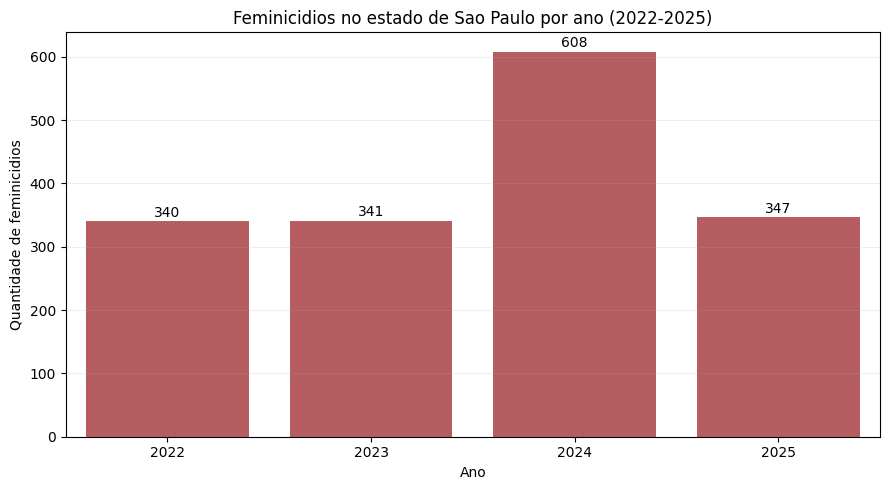

,ANO_ESTATISTICA,QTD_FEMINICIDIOS
0,2022,340
1,2023,341
2,2024,608
3,2025,347


In [3]:
feminicidios_por_ano = (
    df.assign(ANO_ESTATISTICA=df["ANO_ESTATISTICA"].astype("Int64"))
      .groupby("ANO_ESTATISTICA", dropna=True)
      .size()
      .reset_index(name="QTD_FEMINICIDIOS")
      .sort_values("ANO_ESTATISTICA")
)

plt.figure(figsize=(9, 5))
sns.barplot(data=feminicidios_por_ano, x="ANO_ESTATISTICA", y="QTD_FEMINICIDIOS", color="#C44E52")
plt.title("Feminicidios no estado de Sao Paulo por ano (2022-2025)")
plt.xlabel("Ano")
plt.ylabel("Quantidade de feminicidios")
plt.grid(axis="y", alpha=0.2)

for i, valor in enumerate(feminicidios_por_ano["QTD_FEMINICIDIOS"]):
    plt.text(i, valor + 2, f"{valor}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

feminicidios_por_ano

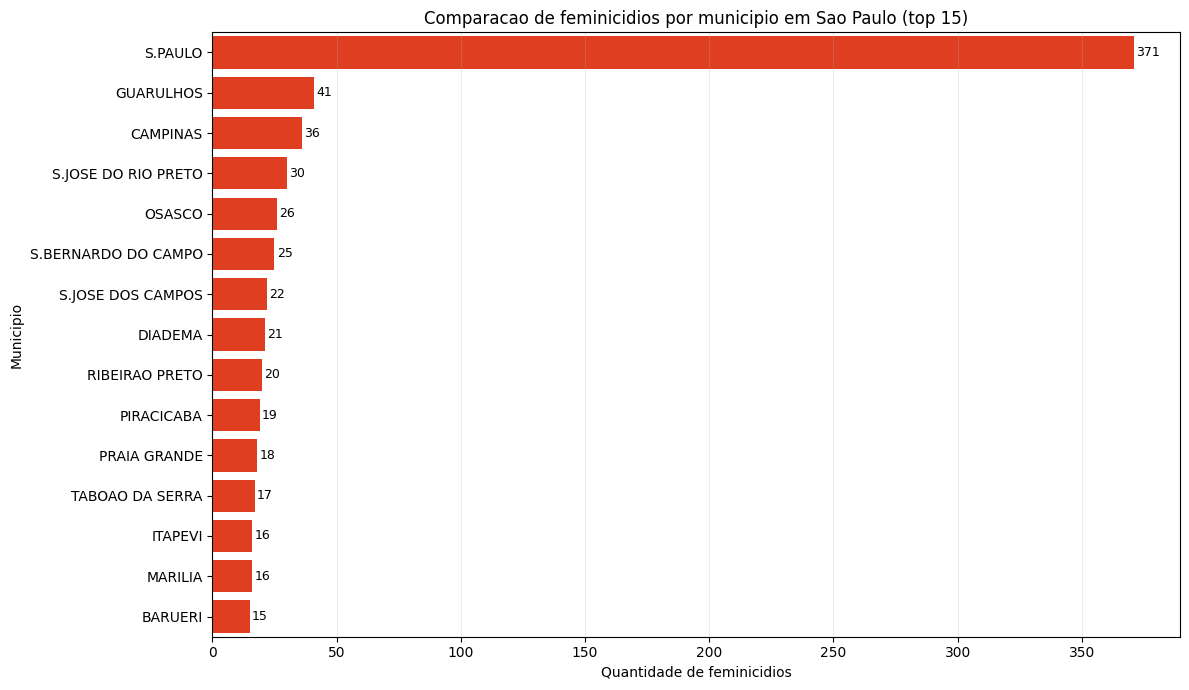

,NOME_MUNICIPIO,QTD_FEMINICIDIOS
284,S.PAULO,371
117,GUARULHOS,41
58,CAMPINAS,36
278,S.JOSE DO RIO PRETO,30
211,OSASCO,26
265,S.BERNARDO DO CAMPO,25
279,S.JOSE DOS CAMPOS,22
84,DIADEMA,21
254,RIBEIRAO PRETO,20
233,PIRACICABA,19


In [4]:
feminicidios_por_municipio = (
    df.dropna(subset=["NOME_MUNICIPIO"])
      .assign(NOME_MUNICIPIO=df["NOME_MUNICIPIO"].astype(str).str.strip())
      .groupby("NOME_MUNICIPIO")
      .size()
      .reset_index(name="QTD_FEMINICIDIOS")
      .sort_values("QTD_FEMINICIDIOS", ascending=False)
)

top_municipios = feminicidios_por_municipio.head(15)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_municipios,
    y="NOME_MUNICIPIO",
    x="QTD_FEMINICIDIOS",
    color="#FF2A00"
)
plt.title("Comparacao de feminicidios por municipio em Sao Paulo (top 15)")
plt.xlabel("Quantidade de feminicidios")
plt.ylabel("Municipio")
plt.grid(axis="x", alpha=0.25)

for index, value in enumerate(top_municipios["QTD_FEMINICIDIOS"]):
    plt.text(value + 1, index, f"{value}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

top_municipios

## Divisão em Subregiões

In [ ]:
DEMACRO = [ 
    'CARAPICUIBA',
    'DIADEMA',
    'FRANCO DA ROCHA',
    'GUARULHOS',
    'MOGI DAS CRUZES',
    'OSASCO',
    'SANTO ANDRE',
    'S.BERNARDO DO CAMPO',
    'TABOAO DA SERRA'
]

INTERIOR = [i for i in feminicidios_por_municipio.NOME_MUNICIPIO if i not in DEMACRO and i != 'S.PAULO']

In [53]:

feminicidios_por_subregiao = {
    'CAPITAL' : feminicidios_por_municipio.QTD_FEMINICIDIOS.loc[feminicidios_por_municipio.NOME_MUNICIPIO == "S.PAULO"].iloc[0],
    'DEMACRO': feminicidios_por_municipio.loc[feminicidios_por_municipio.NOME_MUNICIPIO.isin(DEMACRO)].QTD_FEMINICIDIOS.sum(),
    'INTERIOR': feminicidios_por_municipio.loc[feminicidios_por_municipio.NOME_MUNICIPIO.isin(INTERIOR)].QTD_FEMINICIDIOS.sum(),
}

feminicidios_por_subregiao

{'CAPITAL': np.int64(371),
 'DEMACRO': np.int64(165),
 'INTERIOR': np.int64(1100)}

In [5]:
jan_2023 = (
    df.assign(
        ANO_ESTATISTICA=df["ANO_ESTATISTICA"].astype("Int64"),
        MES_ESTATISTICA=df["MES_ESTATISTICA"].astype("Int64")
    )
    .query("ANO_ESTATISTICA == 2023 and MES_ESTATISTICA == 7")
    .shape[0]
)

print(f"Feminicidios em janeiro de 2023: {jan_2023}")
jan_2023

Feminicidios em janeiro de 2023: 12


12